In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.8 MB/s eta 0:00:00


In [2]:
import cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
data_path = Path("../input/datasets/loubl00m/drones")
train_path = data_path / "train"
val_path = data_path / "valid"
input_shape = (640, 640,)

In [4]:
img_paths = list((train_path / "images").iterdir())
label_paths = [train_path / "labels" / img.with_suffix(".txt").name for img in img_paths]

In [21]:
def read_images(path):
    images = [cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB) for img_path in path]
    return np.stack(images)
    
def read_labels(path):
    labels = []
    for file in path:
        with open(file, 'r') as f:
            labels.append(list(map(float, f.read().split())))
    return labels
    
train_images = read_images(img_paths)
train_labels = read_labels(label_paths)

In [22]:
val_img_paths = list((val_path / "images").iterdir())
val_label_paths = [val_path / "labels" / img.with_suffix(".txt").name for img in val_img_paths]
val_images = read_images(val_img_paths)
val_labels = read_labels(val_label_paths)

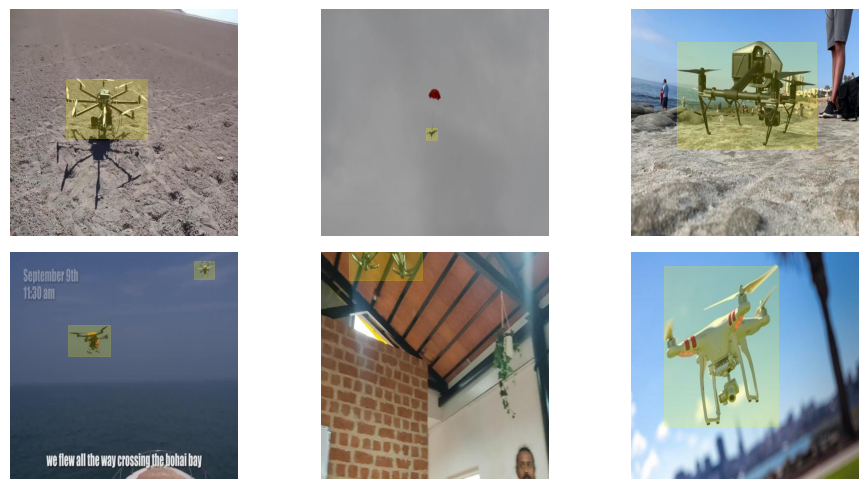

In [24]:
def show_label(image, label, ax, img_shape = (640, 640, 3)):
    h, w, _ = img_shape
    ax.set_axis_off()
    ax.imshow(image)
    for i in range(0, len(label), 5):
        _, bx, by, bw, bh = label[i: i + 5]
        bx1 = (bx - bw / 2) * w
        by1 = (by - bh / 2) * h
        
        rect = patches.Rectangle(
            xy=(bx1, by1),       
            width=bw * w,          
            height=bh * h,       
            linewidth=0.5,
            edgecolor='yellow',
            facecolor='yellow',
            alpha=0.2,
            label='Drone'
        )
        ax.add_patch(rect)

m, n = 2, 3
fig, axes = plt.subplots(m, n, figsize=(10, 5))
for ax, image, label in zip(axes.flatten(), train_images, train_labels):
    show_label(image, label, ax)

plt.tight_layout()
plt.show()

## Model

In [7]:
model_path = "/kaggle/input/models/loubl00m/yolov8/pytorch/default/1/yolo26n.pt"
device = device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = YOLO(model_path)

In [8]:
results = model.train(data=data_path / "data.yaml", epochs=100, imgsz=640, device=device, pretrained = True)

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../input/datasets/loubl00m/drones/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/models/loubl00m/yolov8/pytorch/default/1/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

In [10]:
metrics = model.val()

Ultralytics 8.4.62 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.7±0.1 ms, read: 42.2±20.8 MB/s, size: 32.0 KB)
val: Scanning /kaggle/input/datasets/loubl00m/drones/valid/labels... 157 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 157/157 783.3it/s 0.2s3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/loubl00m/drones/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.8it/s 2.7s.2ss
                   all        157        214      0.961      0.921      0.938      0.729
Speed: 3.4ms preprocess, 4.4ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2


np.float64(0.7293820262390596)

In [32]:
x_test = val_images[5]
y_test = val_labels[5]

model(x_test)


0: 640x640 1 drone, 14.4ms
Speed: 2.6ms preprocess, 14.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'drone'}
 obb: None
 orig_img: array([[[241, 242, 247],
         [241, 242, 247],
         [240, 241, 246],
         ...,
         [ 95, 122, 167],
         [ 95, 122, 167],
         [ 95, 122, 167]],
 
        [[241, 242, 247],
         [241, 242, 247],
         [240, 241, 246],
         ...,
         [ 95, 122, 167],
         [ 95, 122, 167],
         [ 95, 122, 167]],
 
        [[241, 242, 247],
         [241, 242, 247],
         [240, 241, 246],
         ...,
         [ 95, 122, 167],
         [ 95, 122, 167],
         [ 95, 122, 167]],
 
        ...,
 
        [[157, 171,  96],
         [153, 167,  92],
         [152, 166,  91],
         ...,
         [140, 136,  88],
         [140, 136,  89],
         [138, 134,  87]],
 
        [[162, 176, 101],
         [156, 170,  95],
         [153, 167,  92],
         ...,
         [142, 138,